In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/internet-traffic-3/cell_4760.csv


In [18]:
import os
import glob
import json
import math
import warnings
from pprint import pprint
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.layers import ConvLSTM2D, Conv3D, Dense, Input, Add, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [19]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/internet-traffic-3/cell_4760.csv


Outlier Analysis Report (Cell 5161)
Total outliers detected: 79
Top 5 highest positive outliers:
                               datetime  original_value    residual   z_score
datetime                                                                     
2013-11-23 00:30:00 2013-11-23 00:30:00      832.001654  420.954707  4.328279
2013-11-11 12:30:00 2013-11-11 12:30:00     1383.074352  418.427589  4.302293
2013-11-04 11:20:00 2013-11-04 11:20:00     1347.118681  410.637826  4.222193
2013-11-12 04:40:00 2013-11-12 04:40:00      965.060834  403.833635  4.152227
2013-11-13 12:20:00 2013-11-13 12:20:00     1615.740648  394.822144  4.059564

Top 5 lowest negative outliers:
                               datetime  original_value    residual   z_score
datetime                                                                     
2013-11-03 12:30:00 2013-11-03 12:30:00      267.297736 -362.979231 -3.732740
2013-11-07 10:10:00 2013-11-07 10:10:00      727.061074 -372.766056 -3.833376
2013-11-12 1

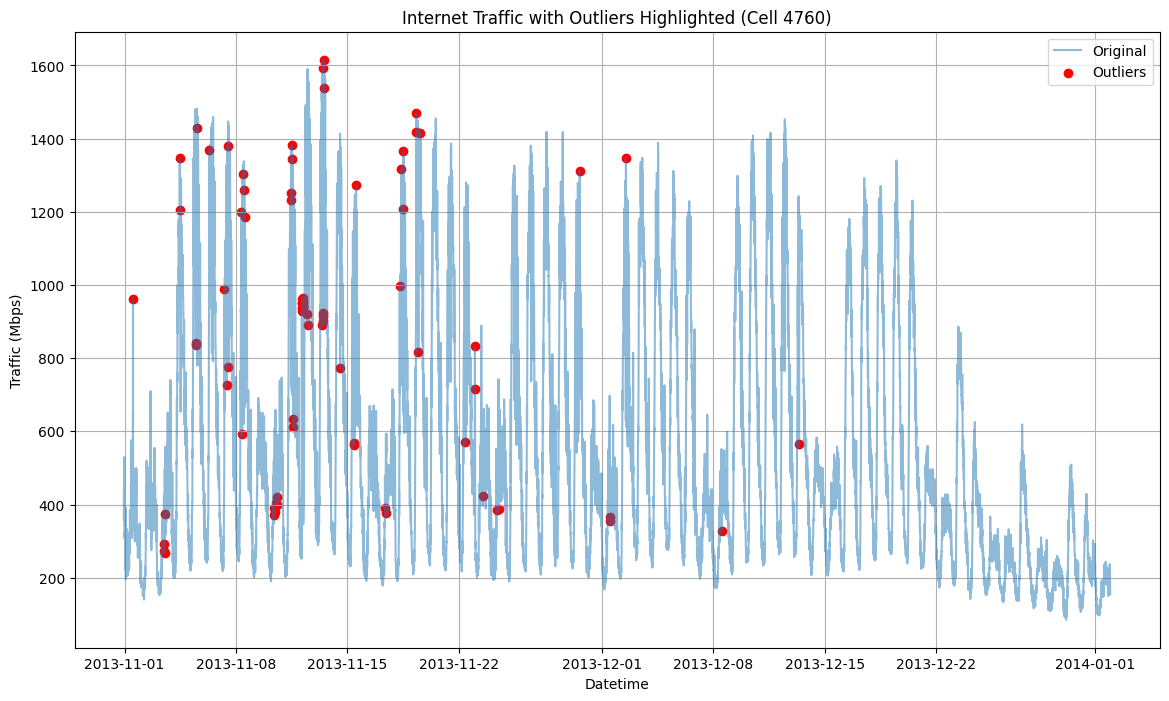

/tmp/ipykernel_35/2407364279.py:55: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['4760'] = data['4760'].interpolate(method='time').fillna(method='bfill').fillna(method='ffill')


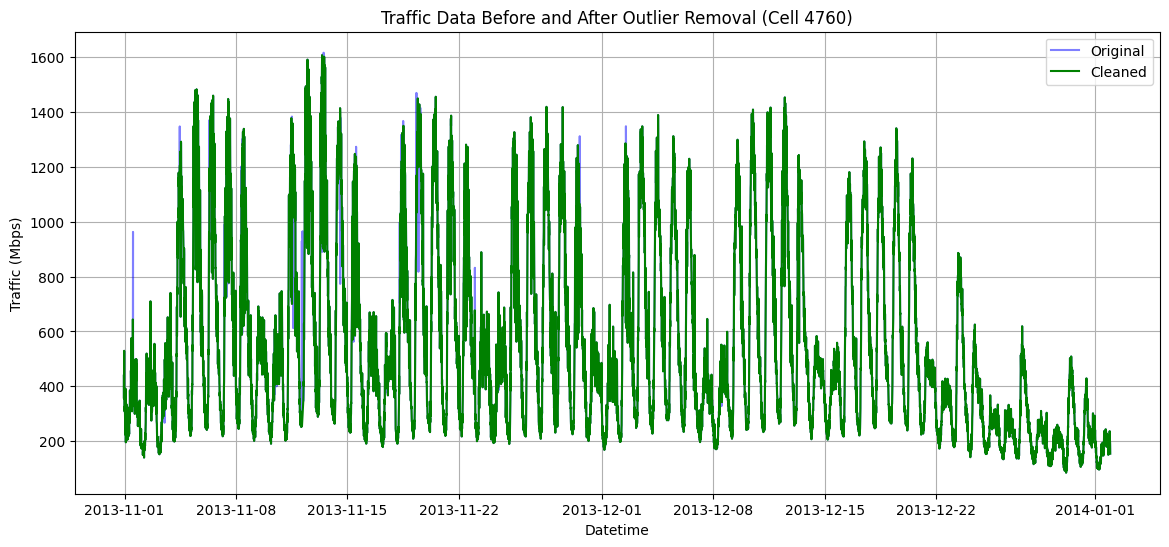

In [20]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Load and prepare data
data = pd.read_csv('/kaggle/input/internet-traffic-3/cell_4760.csv', 
                  parse_dates=['datetime'], 
                  index_col='datetime')
data = data.asfreq('10min')
original_data = data.copy()

# STL Decomposition
period = 144  # Daily seasonality (6*24=144 for 10min intervals)
stl = STL(data['4760'], period=period)
result = stl.fit()

# Enhanced Outlier Analysis
residuals = result.resid
z_scores = (residuals - residuals.mean()) / residuals.std()
outlier_mask = np.abs(z_scores) > 3

# Create outlier dataframe for detailed analysis
outliers = pd.DataFrame({
    'datetime': original_data.index[outlier_mask],
    'original_value': original_data.loc[outlier_mask, '4760'],
    'residual': residuals[outlier_mask],
    'z_score': z_scores[outlier_mask]
    
}).sort_values('z_score', ascending=False)

# Print comprehensive outlier report
print(f"Outlier Analysis Report (Cell 5161)")
print("="*50)
print(f"Total outliers detected: {len(outliers)}")
print(f"Top 5 highest positive outliers:")
print(outliers.head())
print("\nTop 5 lowest negative outliers:")
print(outliers.tail())

# Visualize outliers in context
plt.figure(figsize=(14, 8))
plt.plot(data['4760'], label='Original', alpha=0.5)
plt.scatter(outliers['datetime'], outliers['original_value'], 
           color='red', label='Outliers')
plt.title('Internet Traffic with Outliers Highlighted (Cell 4760)')
plt.xlabel('Datetime')
plt.ylabel('Traffic (Mbps)')
plt.legend()
plt.grid(True)
plt.show()

# Handle outliers (interpolate)
data.loc[outlier_mask, '4760'] = np.nan
data['4760'] = data['4760'].interpolate(method='time').fillna(method='bfill').fillna(method='ffill')

# Plot before/after comparison
plt.figure(figsize=(14, 6))
plt.plot(original_data['4760'], label='Original', color='blue', alpha=0.5)
plt.plot(data['4760'], label='Cleaned', color='green')
plt.title('Traffic Data Before and After Outlier Removal (Cell 4760)')
plt.xlabel('Datetime')
plt.ylabel('Traffic (Mbps)')
plt.legend()
plt.grid(True)
plt.show()



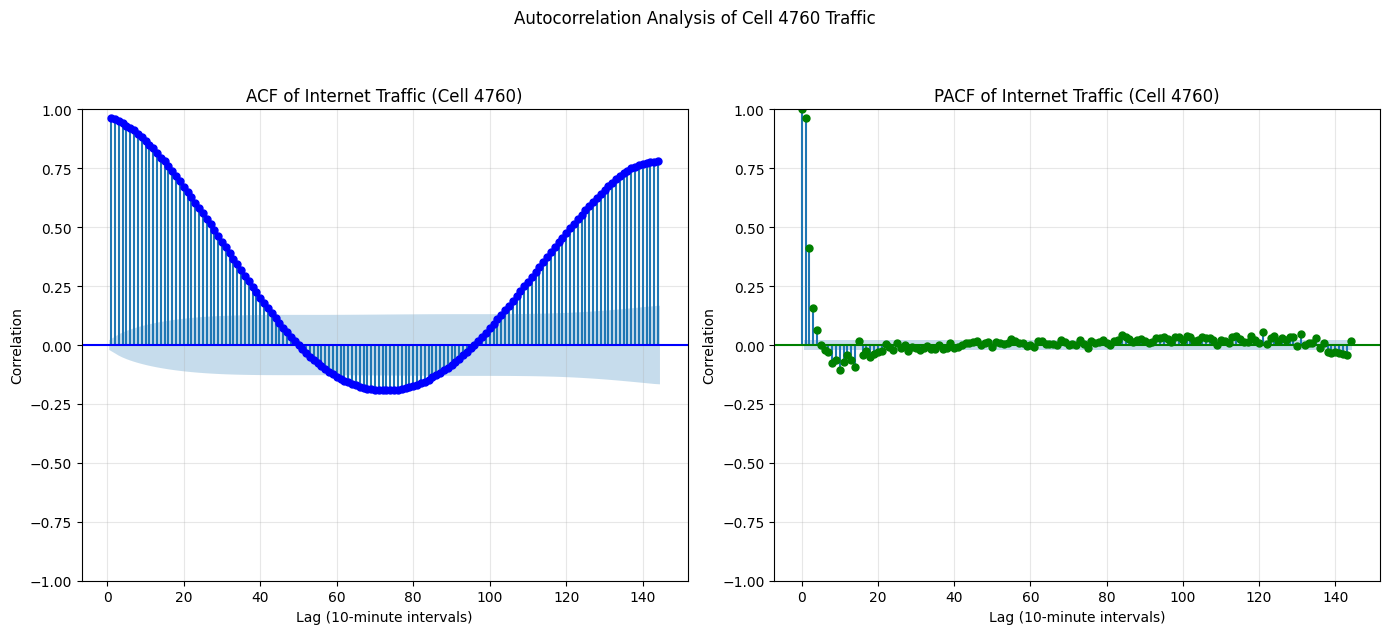

In [52]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot ACF (Autocorrelation Function)
plot_acf(data['4760'], 
         lags=144, 
         ax=axes[0],
         title='ACF of Internet Traffic (Cell 4760)',
         color='blue',
         alpha=0.05,  # Confidence interval
         zero=False)  # Don't plot lag 0 correlation

# Plot PACF (Partial Autocorrelation Function)
plot_pacf(data['4760'], 
          lags=144, 
          ax=axes[1],
          title='PACF of Internet Traffic (Cell 4760)',
          color='green',
          method='ywm',  # Yule-Walker with adjustment
          alpha=0.05)  # Confidence interval

# Enhance formatting
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Lag (10-minute intervals)')
    ax.set_ylabel('Correlation')

plt.suptitle('Autocorrelation Analysis of Cell 4760 Traffic', y=1.05)
plt.tight_layout()
plt.show()

In [22]:
from statsmodels.tsa.stattools import adfuller

def perform_adf_test(series, title):
    print(f"\nADF Test for {title} (Cell 4760):")
    result = adfuller(series.dropna())
    
    # Print test results
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    # Enhanced interpretation
    if result[1] < 0.05:
        print("\nConclusion: Series is stationary (reject null hypothesis at 5% significance level)")
        print("Implication: No differencing required for modeling")
    else:
        print("\nConclusion: Series is non-stationary (fail to reject null hypothesis)")
        print("Implication: Consider differencing or transformation")
    
    # Return test results for further analysis
    return {
        'adf_statistic': result[0],
        'p_value': result[1],
        'critical_values': result[4],
        'is_stationary': result[1] < 0.05
    }




In [23]:
def perform_kpss_test(series, title):
    print(f"\nKPSS Test for {title} (Cell 4760):")
    result = kpss(series.dropna(), regression='c', nlags='auto')
    
    # Print test results
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[3].items():
        print(f'\t{key}: {value:.4f}')
    
    if result[1] < 0.05:
        print("\nConclusion: Series is non-stationary (reject null hypothesis)")
    else:
        print("\nConclusion: Series is stationary (fail to reject null hypothesis)")
    
    return {
        'kpss_statistic': result[0],
        'p_value': result[1],
        'critical_values': result[3],
        'is_stationary': result[1] >= 0.05  # Note: reversed from ADF
    }


In [24]:
# Run both tests
adf_results = perform_adf_test(data['4760'], "Cleaned Traffic Data")
kpss_results = perform_kpss_test(data['4760'], "Cleaned Traffic Data")

# Combined interpretation
print("\n" + "="*50)
print("Combined Stationarity Analysis:")

if adf_results['is_stationary'] and kpss_results['is_stationary']:
    print("✅ Tests agree: SERIES IS STATIONARY")
    print("📌 Modeling recommendation: Use ARIMA/SARIMA with d=0")
elif not adf_results['is_stationary'] and not kpss_results['is_stationary']:
    print("❌ Tests agree: SERIES IS NON-STATIONARY")
    print("📌 Modeling recommendation: Apply differencing (d=1 or d=2)")
else:
    print("⚠️ Tests disagree: SERIES MAY BE TREND-STATIONARY")
    print("📌 Modeling recommendation: Consider including a trend term or differencing once")



ADF Test for Cleaned Traffic Data (Cell 4760):
ADF Statistic: -12.7677
p-value: 0.0000
Critical Values:
	1%: -3.4311
	5%: -2.8619
	10%: -2.5669

Conclusion: Series is stationary (reject null hypothesis at 5% significance level)
Implication: No differencing required for modeling

KPSS Test for Cleaned Traffic Data (Cell 4760):
KPSS Statistic: 1.7318
p-value: 0.0100
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390

Conclusion: Series is non-stationary (reject null hypothesis)

Combined Stationarity Analysis:
⚠️ Tests disagree: SERIES MAY BE TREND-STATIONARY
📌 Modeling recommendation: Consider including a trend term or differencing once


/tmp/ipykernel_35/3697473083.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


[INFO] Decomposing with frequency '144' (1 days 00:00:00 window) using Additive model
[INFO] Plot saved as 'decomposition_cell_4760_additive.png'


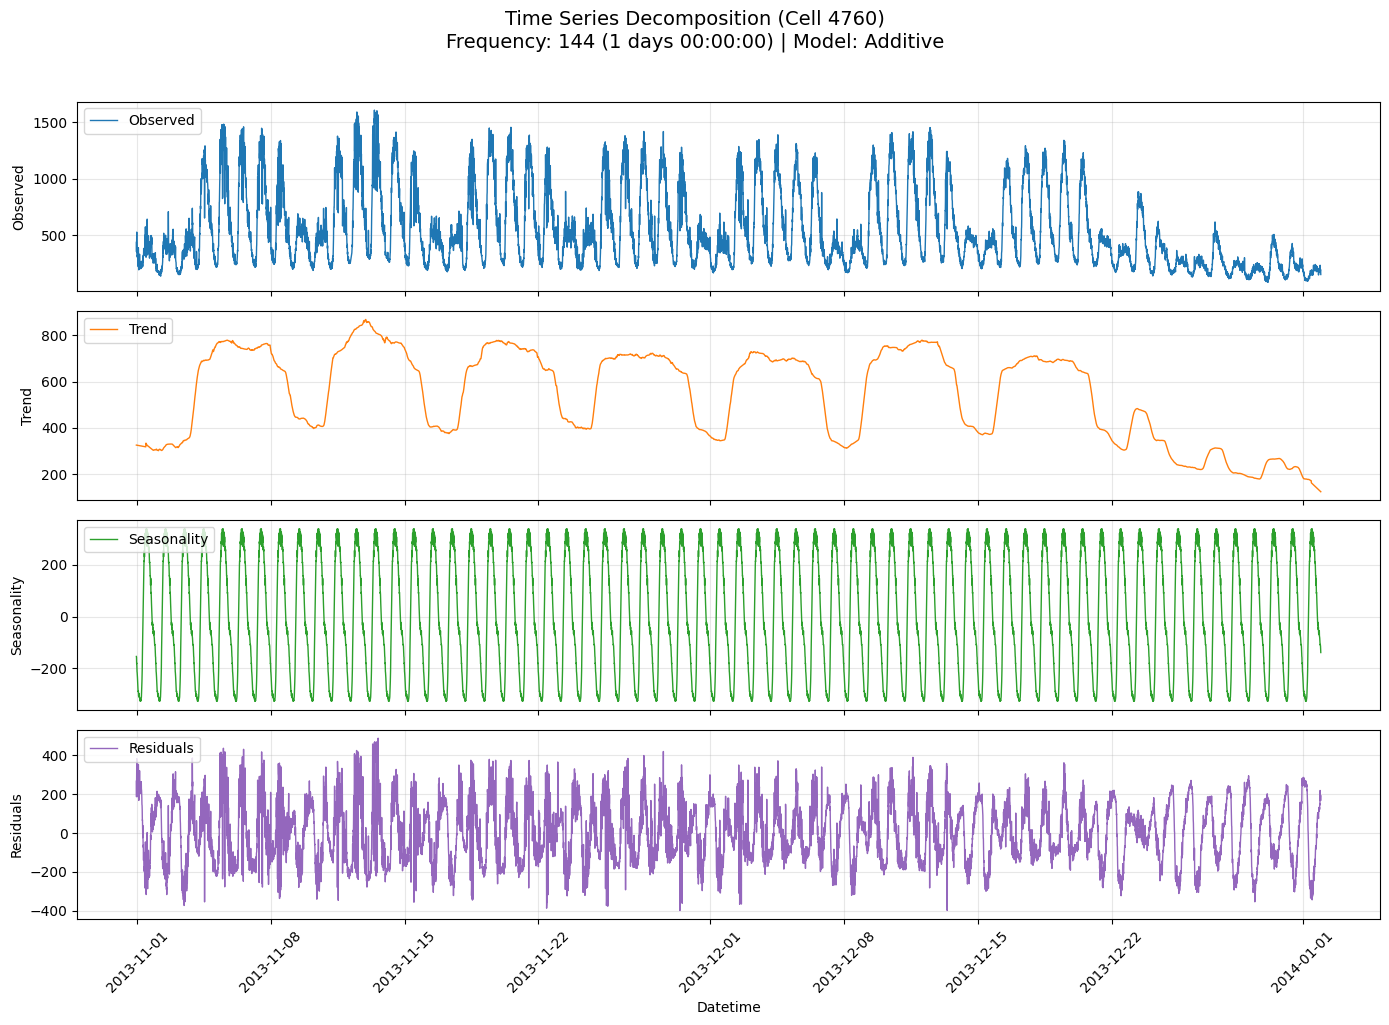

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.tseries.frequencies import to_offset

def decompose_series(series, freq, model='additive', cell_id='4760', save_fig=False):
    """
    Enhanced time series decomposition with diagnostics and visualization.
    
    Parameters:
    - series (pd.Series): Time series data with datetime index.
    - freq (int): Seasonal period (e.g., 144 for daily seasonality in 10-min intervals).
    - model (str): Decomposition model - 'additive' or 'multiplicative'.
    - cell_id (str): Identifier for plot titles and saving.
    - save_fig (bool): Whether to save the plot as PNG.
    
    Returns:
    - result: Decomposition object (trend, seasonal, resid, observed)
    """
    
    # === Input validation ===
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DatetimeIndex")
    
    inferred_freq = pd.infer_freq(series.index)
    if not inferred_freq:
        raise ValueError("Unable to infer a consistent frequency from datetime index")

    # Report actual seasonal window in time
    offset = to_offset(inferred_freq)
    seasonal_duration = pd.Timedelta(offset) * freq
    print(f"[INFO] Decomposing with frequency '{freq}' ({seasonal_duration} window) using {model.title()} model")
    
    # Handle missing data if any
    if series.isna().sum() > 0:
        print("[INFO] Missing values detected — applying linear time interpolation")
        series = series.interpolate(method='time')
    
    # === Perform decomposition ===
    result = seasonal_decompose(series, model=model, period=freq, extrapolate_trend='freq')

    # === Plotting ===
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(
        f'Time Series Decomposition (Cell {cell_id})\n'
        f'Frequency: {freq} ({seasonal_duration}) | Model: {model.title()}',
        y=1.02, fontsize=14
    )

    labels = ['Observed', 'Trend', 'Seasonality', 'Residuals']
    components = [series, result.trend, result.seasonal, result.resid]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

    for ax, label, comp, color in zip(axes, labels, components, colors):
        ax.plot(comp, label=label, color=color, linewidth=1)
        ax.set_ylabel(label, fontsize=10)
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Datetime', fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Optional: Save figure
    if save_fig:
        filename = f'decomposition_cell_{cell_id}_{model}.png'
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"[INFO] Plot saved as '{filename}'")

    plt.show()
    return result

# === Usage example ===
decomposition_result = decompose_series(
    data['4760'], 
    freq=144,              # e.g., 10-min data * 144 = 1 day
    model='additive',      # or 'multiplicative' if needed
    cell_id='4760',
    save_fig=True          # set to False to disable saving
)


Train/Test Split Summary
Train Period : 2013-11-01 00:00:00 → 2013-12-20 23:50:00
Test Period  : 2013-12-21 00:00:00 → 2013-12-30 23:50:00
Train Samples: 7,200
Test Samples : 1,440


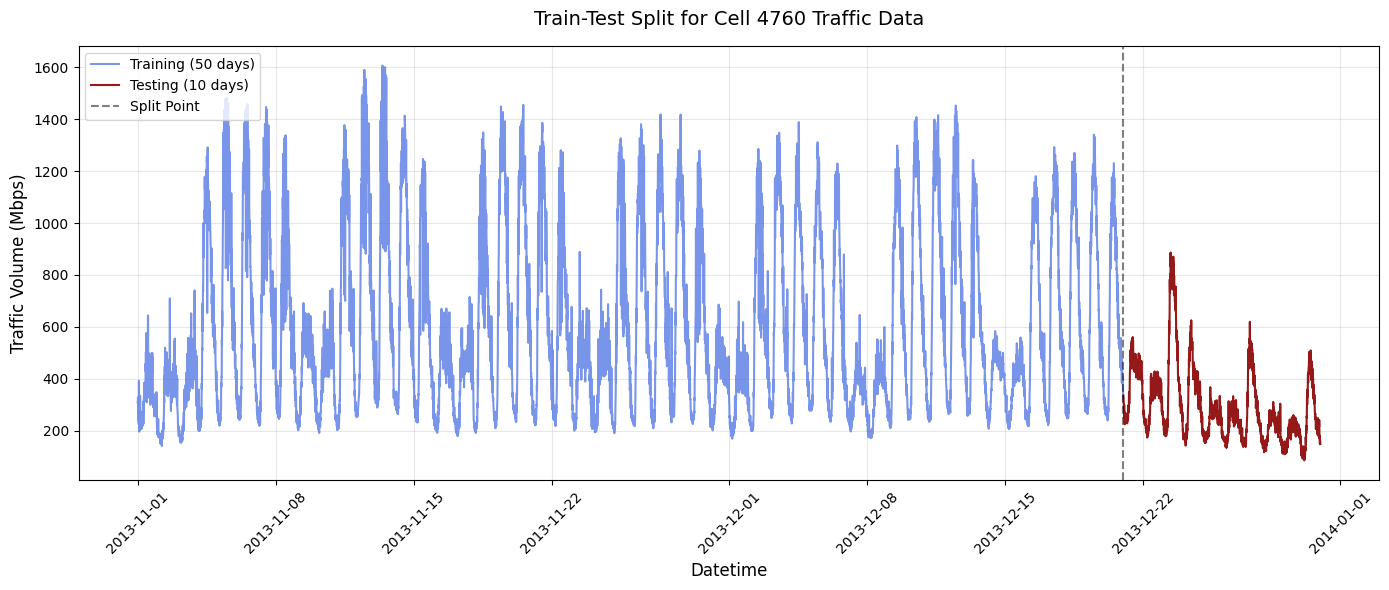

In [39]:
import matplotlib.pyplot as plt

# === Step 1: Prepare the target variable ===
target_col = '4760'

if target_col not in data.columns:
    raise ValueError(f"Column '{target_col}' not found. Available columns: {data.columns.tolist()}")

y = data[target_col]

# === Step 2: Define split boundaries ===
train_start = '2013-11-01'
train_end = '2013-12-20 23:50:00'
test_start = '2013-12-21 00:00:00'
test_end = '2013-12-30 23:50:00'

# Ensure datetime index is sorted
y = y.sort_index()

# === Step 3: Perform the split ===
train = y.loc[train_start:train_end]
test = y.loc[test_start:test_end]

# === Step 4: Validate split ranges ===
print("="*40)
print("Train/Test Split Summary")
print("="*40)
print(f"Train Period : {train.index.min()} → {train.index.max()}")
print(f"Test Period  : {test.index.min()} → {test.index.max()}")
print(f"Train Samples: {len(train):,}")
print(f"Test Samples : {len(test):,}")
print("="*40)

# === Step 5: Visualize the split ===
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Training (50 days)', color='royalblue', alpha=0.7)
plt.plot(test.index, test, label='Testing (10 days)', color='darkred', alpha=0.9)

# Optional: Add vertical line to mark split point
plt.axvline(pd.to_datetime(test_start), color='black', linestyle='--', alpha=0.5, label='Split Point')

plt.title(f'Train-Test Split for Cell {target_col} Traffic Data', fontsize=14, pad=15)
plt.xlabel('Datetime', fontsize=12)
plt.ylabel('Traffic Volume (Mbps)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [48]:
from statsmodels.tsa.arima.model import ARIMA
# Define the ARIMA model with order (p=14, d=1, q=4)
model = ARIMA(train, order=(11, 1, 5))

# Fit the model to training data
arima_fit = model.fit()

# Summary of the model
print("Model fitted successfully!")
print(arima_fit.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model fitted successfully!
                               SARIMAX Results                                
Dep. Variable:                   4760   No. Observations:                 7200
Model:                ARIMA(11, 1, 5)   Log Likelihood              -42541.640
Date:                Wed, 28 May 2025   AIC                          85117.280
Time:                        15:47:25   BIC                          85234.269
Sample:                    11-01-2013   HQIC                         85157.536
                         - 12-20-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3466      0.112     -3.100      0.002      -0.566      -0.127
ar.L2          0.2051      0.141      1.458      0.145      -0.071       0.481
ar.L3          0.5442    

In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

# === Forecast 10 hours ahead (10-min intervals → 60 steps) ===
forecast_steps = 6 * 10  # 6 points/hour
forecast = arima_fit.forecast(steps=forecast_steps)

# === Align forecast with test data ===
test_subset = test[:forecast_steps]

# === Compute Error Metrics ===
rmse = np.sqrt(mean_squared_error(test_subset, forecast))
nrmse = rmse / (test_subset.max() - test_subset.min())
accuracy = 1 - nrmse

# === Print Results ===
print("\n=== Forecast Evaluation (10 hours) ===")
print(f"RMSE                    : {rmse:.3f}")
print(f"NRMSE                   : {nrmse:.3%}")
print(f"Accuracy (1 - NRMSE)    : {accuracy:.3%}")



=== Forecast Evaluation (10 hours) ===
RMSE                    : 106.573
NRMSE                   : 34.591%
Accuracy (1 - NRMSE)    : 65.409%


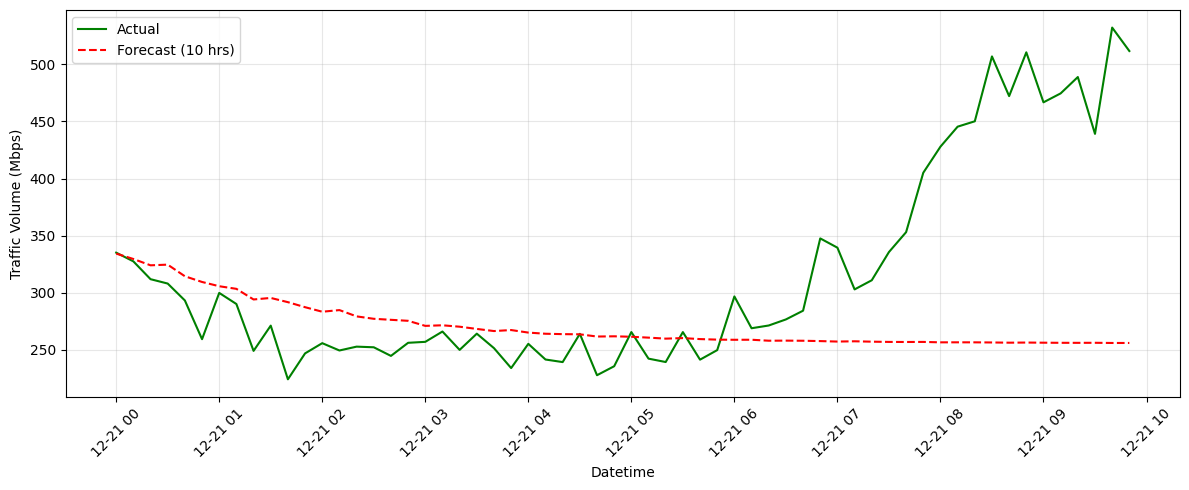

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test_subset.index, test_subset, label='Actual', color='green')
plt.plot(test_subset.index, forecast, label='Forecast (10 hrs)', color='red', linestyle='--')
# plt.title('ARIMA(2,1,4) - 10 Hour Forecast vs Actual', pad=15)
plt.xlabel('Datetime')
plt.ylabel('Traffic Volume (Mbps)')
plt.legend()

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_35/365830086.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_{lag}'] = df[target_col].shift(lag)
/tmp/ipykernel_35/365830086.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_{lag}'] = df[target_col].shift(lag)
/tmp/ipykernel_35/365830086.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, 

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[262]	valid_0's l1: 33.2328
MAE: 19.92 Mbps
MAPE: 5.34%
RMSE: 26.60 Mbps
NRMSE: 0.0799 → Accuracy: 92.01%


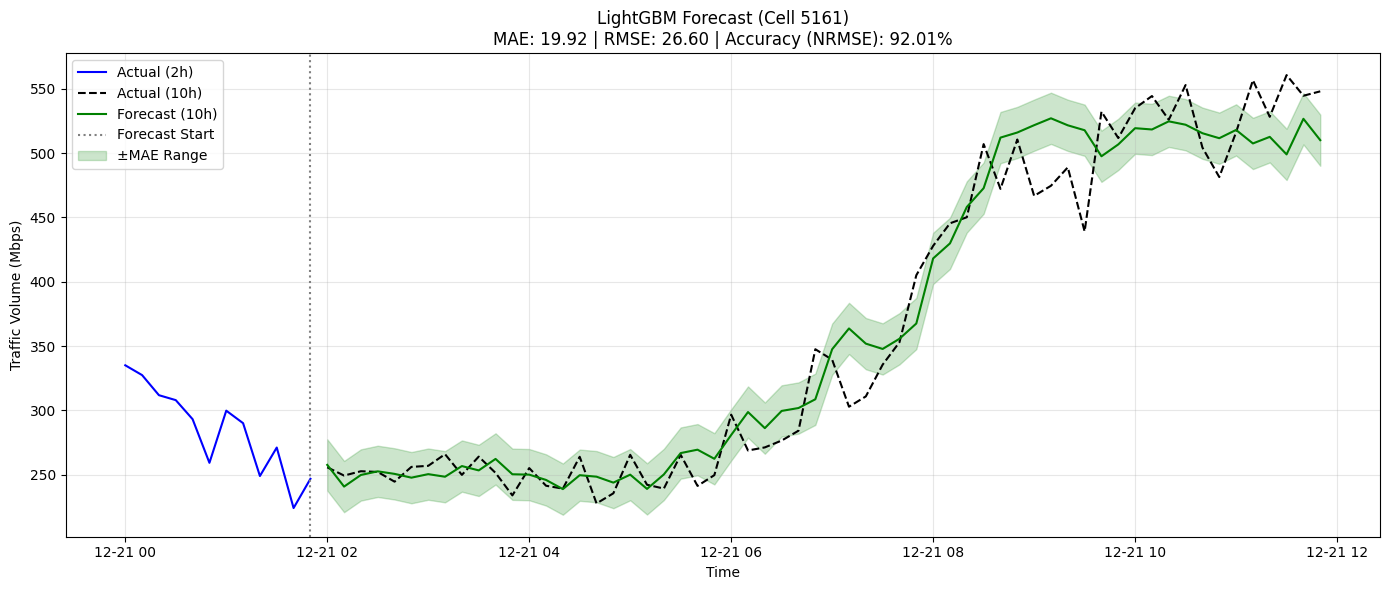

In [30]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Feature Engineering
def create_features(df, target_col='4760', lags=144, rolling_windows=[24, 72, 144]):
    df = df.copy()
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    for window in rolling_windows:
        df[f'rolling_mean_{window}'] = df[target_col].rolling(window).mean()
        df[f'rolling_std_{window}'] = df[target_col].rolling(window).std()
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    return df.dropna()

# Prepare data
data_engineered = create_features(data[['4760']].copy())

# Train-test split (50d train / 10d test)
train = data_engineered.loc['2013-11-01':'2013-12-20']
test = data_engineered.loc['2013-12-21':'2013-12-30']

X_train, y_train = train.drop('4760', axis=1), train['4760']
X_test_full, y_test_full = test.drop('4760', axis=1), test['4760']

# LightGBM parameters
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.02,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 2,
    'min_child_samples': 10,
    'lambda_l1': 0.2,
    'lambda_l2': 0.2,
    'verbose': -1
}

# Train model
model = lgb.LGBMRegressor(**params, n_estimators=1000)
model.fit(X_train, y_train,
          eval_set=[(X_test_full, y_test_full)],
          callbacks=[lgb.early_stopping(stopping_rounds=50)])

# Forecasting: 2h context + 10h prediction
context_steps = 12  # 2h
forecast_steps = 60  # 10h

X_context = X_test_full.iloc[:context_steps].copy()
y_context = y_test_full.iloc[:context_steps].copy()

X_forecast = X_test_full.iloc[context_steps:context_steps + forecast_steps].copy()
y_forecast_actual = y_test_full.iloc[context_steps:context_steps + forecast_steps].copy()

y_forecast_pred = model.predict(X_forecast)

# Evaluation metrics
mae = mean_absolute_error(y_forecast_actual, y_forecast_pred)
mape = mean_absolute_percentage_error(y_forecast_actual, y_forecast_pred) * 100
rmse = mean_squared_error(y_forecast_actual, y_forecast_pred, squared=False)
nrmse = rmse / (y_forecast_actual.max() - y_forecast_actual.min())
accuracy = (1 - nrmse) * 100

# Print all metrics
print(f"MAE: {mae:.2f} Mbps")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f} Mbps")
print(f"NRMSE: {nrmse:.4f} → Accuracy: {accuracy:.2f}%")

# Plot results
plt.figure(figsize=(14, 6))
plt.plot(y_context.index, y_context, label='Actual (2h)', color='blue')
plt.plot(y_forecast_actual.index, y_forecast_actual, label='Actual (10h)', color='black', linestyle='--')
plt.plot(y_forecast_actual.index, y_forecast_pred, label='Forecast (10h)', color='green')

plt.axvline(y_context.index[-1], color='gray', linestyle=':', lw=1.5, label='Forecast Start')
plt.fill_between(y_forecast_actual.index,
                 y_forecast_pred - mae,
                 y_forecast_pred + mae,
                 color='green', alpha=0.2, label='±MAE Range')
plt.title(f'LightGBM Forecast (Cell 5161)\nMAE: {mae:.2f} | RMSE: {rmse:.2f} | Accuracy (NRMSE): {accuracy:.2f}%')
plt.xlabel('Time')
plt.ylabel('Traffic Volume (Mbps)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_35/14474727.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_{lag}'] = df[target_col].shift(lag)
/tmp/ipykernel_35/14474727.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag_{lag}'] = df[target_col].shift(lag)
/tmp/ipykernel_35/14474727.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[262]	valid_0's l1: 33.2328


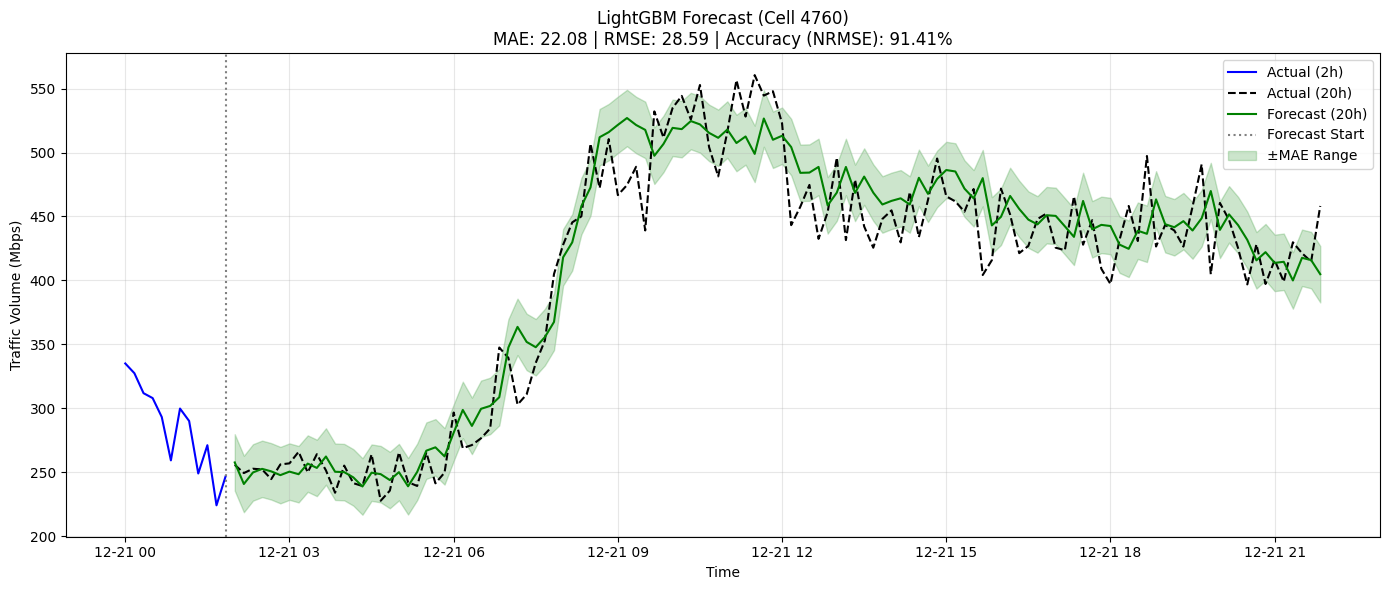

MAE: 22.08 Mbps
MAPE: 5.44%
RMSE: 28.59 Mbps
NRMSE: 0.0859 → Accuracy: 91.41%


In [31]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Load your data first (assuming it's already loaded as 'data')
# and preprocessed similar to previous steps
# For now, we'll simulate the same approach for cell '4760'

# Feature engineering function
def create_features(df, target_col='4760', lags=144, rolling_windows=[24, 72, 144]):
    df = df.copy()
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df[target_col].shift(lag)
    for window in rolling_windows:
        df[f'rolling_mean_{window}'] = df[target_col].rolling(window).mean()
        df[f'rolling_std_{window}'] = df[target_col].rolling(window).std()
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    return df.dropna()

# Apply the feature engineering for cell 4760
data_engineered_4760 = create_features(data[['4760']].copy())

# Train-test split for cell 4760
train_4760 = data_engineered_4760.loc['2013-11-01':'2013-12-20']
test_4760 = data_engineered_4760.loc['2013-12-21':'2013-12-30']

X_train, y_train = train_4760.drop('4760', axis=1), train_4760['4760']
X_test_full, y_test_full = test_4760.drop('4760', axis=1), test_4760['4760']

# LightGBM model parameters (same as before)
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.02,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 2,
    'min_child_samples': 10,
    'lambda_l1': 0.2,
    'lambda_l2': 0.2,
    'verbose': -1
}

# Train model
model = lgb.LGBMRegressor(**params, n_estimators=1000)
model.fit(X_train, y_train,
          eval_set=[(X_test_full, y_test_full)],
          callbacks=[lgb.early_stopping(stopping_rounds=50)])

# Forecasting: 2h context + 20h prediction
context_steps = 12  # 2h
forecast_steps = 120  # 20h

X_context = X_test_full.iloc[:context_steps].copy()
y_context = y_test_full.iloc[:context_steps].copy()

X_forecast = X_test_full.iloc[context_steps:context_steps + forecast_steps].copy()
y_forecast_actual = y_test_full.iloc[context_steps:context_steps + forecast_steps].copy()

y_forecast_pred = model.predict(X_forecast)

# Evaluation metrics
mae = mean_absolute_error(y_forecast_actual, y_forecast_pred)
mape = mean_absolute_percentage_error(y_forecast_actual, y_forecast_pred) * 100
rmse = mean_squared_error(y_forecast_actual, y_forecast_pred, squared=False)
nrmse = rmse / (y_forecast_actual.max() - y_forecast_actual.min())
accuracy = (1 - nrmse) * 100

# Plot results
plt.figure(figsize=(14, 6))
plt.plot(y_context.index, y_context, label='Actual (2h)', color='blue')
plt.plot(y_forecast_actual.index, y_forecast_actual, label='Actual (20h)', color='black', linestyle='--')
plt.plot(y_forecast_actual.index, y_forecast_pred, label='Forecast (20h)', color='green')

plt.axvline(y_context.index[-1], color='gray', linestyle=':', lw=1.5, label='Forecast Start')
plt.fill_between(y_forecast_actual.index,
                 y_forecast_pred - mae,
                 y_forecast_pred + mae,
                 color='green', alpha=0.2, label='±MAE Range')
plt.title(f'LightGBM Forecast (Cell 4760)\nMAE: {mae:.2f} | RMSE: {rmse:.2f} | Accuracy (NRMSE): {accuracy:.2f}%')
plt.xlabel('Time')
plt.ylabel('Traffic Volume (Mbps)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print all metrics
print(f"MAE: {mae:.2f} Mbps")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f} Mbps")
print(f"NRMSE: {nrmse:.4f} → Accuracy: {accuracy:.2f}%")

